## Exploration

Reading in provided data files, mapping them, exploring their attributes.

### Setup

In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2

In [4]:
# read in data
osm_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-osm-paragominas.geojson"))
previsia_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-previsia-2025-paragominas.geojson"))
rivers = gpd.read_file(here("my-data/amzrivnet_v/amzrivnet_v.shp")).to_crs(osm_roads.crs)
test = pd.read_csv(here("challenge-docs/challenge-3/test-pairs.csv"))

In [5]:
# same crs?
assert osm_roads.crs == previsia_roads.crs
assert rivers.crs == osm_roads.crs
osm_roads.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### View data

In [25]:
osm_roads.head()

,osm_id,highway,surface,nome,ref,tracktype,geometry
0,31484259,trunk,None,Belém-Brasília,BR-010,None,"LINESTRING (-47.48585 -3.11580, -47.48441 -3.1..."
1,31484266,trunk,asphalt,Rodovia Belém-Brasília,BR-010,None,"LINESTRING (-47.49626 -3.74754, -47.49600 -3.7..."
2,31484273,trunk,None,Belém-Brasília,BR-010,None,"LINESTRING (-47.47783 -3.08089, -47.47766 -3.0..."
3,31484274,trunk,None,Belém-Brasília,BR-010,None,"LINESTRING (-47.46004 -2.74784, -47.46041 -2.7..."
4,31484287,trunk,None,Rodovia Bernardo Sayão,BR-010,None,"LINESTRING (-47.46705 -3.28915, -47.46825 -3.2..."


In [29]:
previsia_roads.head()

,cat,fonte,geometry
0,1210,previsia_estradas_2025,"LINESTRING (-46.90172 -2.42352, -46.90182 -2.4..."
1,1212,previsia_estradas_2025,"LINESTRING (-46.88051 -2.42478, -46.88032 -2.4..."
2,1225,previsia_estradas_2025,"LINESTRING (-46.88968 -2.42747, -46.89025 -2.4..."
3,1266,previsia_estradas_2025,"LINESTRING (-46.84737 -2.44283, -46.84766 -2.4..."
4,1267,previsia_estradas_2025,"LINESTRING (-46.88438 -2.44445, -46.88485 -2.4..."


In [46]:
test.head()

,id,type,origin_lon,origin_lat,dest_lon,dest_lat,straight_line_km,dest_to_official_road_m,dest_to_previsia_trace_m
0,par-01,office-to-site,-47.344628,-2.995075,-47.721167,-2.907111,42.974,2616,2554
1,par-02,office-to-site,-47.344628,-2.995075,-47.121590,-3.429255,54.032,3181,297
2,par-03,office-to-site,-47.344628,-2.995075,-47.847548,-3.029305,56.036,3490,299
3,par-04,office-to-site,-47.344628,-2.995075,-47.869766,-2.660889,69.090,5594,1089
4,par-05,office-to-site,-47.344628,-2.995075,-47.872321,-2.660534,69.351,5599,928


### Plotting

<Axes: >

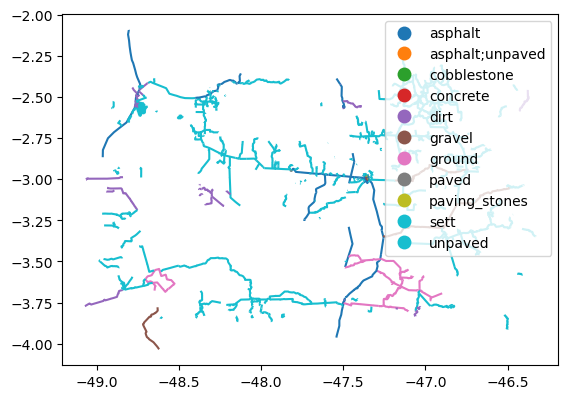

In [42]:
osm_roads.plot(column = 'surface',
               legend = 'True')

<Axes: >

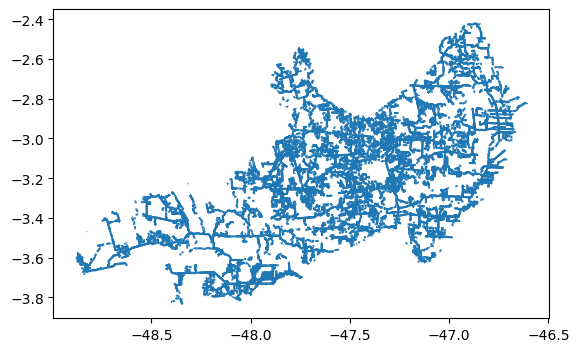

In [23]:
previsia_roads.plot()

<Axes: >

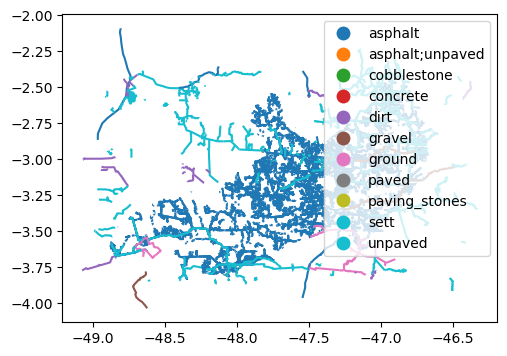

In [44]:
fig, ax = plt.subplots(figsize = (8, 4))
previsia_roads.plot(ax=ax)
osm_roads.plot(ax=ax,
               column = 'surface',
               legend = 'True')

### Prepare OSM geometry for routing

In [52]:
# haversine distance function (as the crow flies)
def haversine(u, v):
    lon1, lat1 = u
    lon2, lat2 = v
    R = 6371000  # meters
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

In [85]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

In [55]:
nx.number_connected_components(G)

55

In [86]:
nx.shortest_path(G, source=, target=point_b, weight='weight')

SyntaxError: invalid syntax (2521373444.py, line 1)

In [57]:
test.head()

,id,type,origin_lon,origin_lat,dest_lon,dest_lat,straight_line_km,dest_to_official_road_m,dest_to_previsia_trace_m
0,par-01,office-to-site,-47.344628,-2.995075,-47.721167,-2.907111,42.974,2616,2554
1,par-02,office-to-site,-47.344628,-2.995075,-47.121590,-3.429255,54.032,3181,297
2,par-03,office-to-site,-47.344628,-2.995075,-47.847548,-3.029305,56.036,3490,299
3,par-04,office-to-site,-47.344628,-2.995075,-47.869766,-2.660889,69.090,5594,1089
4,par-05,office-to-site,-47.344628,-2.995075,-47.872321,-2.660534,69.351,5599,928


In [87]:
test_pairs = test.assign(
    origin=list(zip(test.origin_lon, test.origin_lat)),
    dest=list(zip(test.dest_lon, test.dest_lat))
)

In [88]:
results = []
for _, row in test_pairs.iterrows():
    source = snap(row.origin)
    target = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path = None
        length = None
    results.append({'id': row.id, 'path': path, 'distance_m': length})

results_df = pd.DataFrame(results)

KeyboardInterrupt: 

In [73]:
results_df

,id,path,distance_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47038.370942
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64459.805614
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61367.480771
3,par-04,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020
4,par-05,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",109203.268666
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66543.383079
7,par-08,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020
8,par-09,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020
9,par-10,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020


In [89]:
def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

In [90]:
results_df = pd.DataFrame(results)

In [93]:
results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47038.370942,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64459.805614,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61367.480771,0.000214,0.031455,3491.463331
3,par-04,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020,0.000214,0.050589,5615.349448
4,par-05,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",109203.268666,0.000214,0.005756,638.924562
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66543.383079,0.000214,0.028818,3198.852427
7,par-08,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020,0.000214,0.054815,6084.453462
8,par-09,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020,0.000214,0.055747,6187.959412
9,par-10,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",233779.645020,0.000214,0.050668,5624.107730


In [92]:
# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

In [83]:
test

,id,type,origin_lon,origin_lat,dest_lon,dest_lat,straight_line_km,dest_to_official_road_m,dest_to_previsia_trace_m
0,par-01,office-to-site,-47.344628,-2.995075,-47.721167,-2.907111,42.974,2616,2554
1,par-02,office-to-site,-47.344628,-2.995075,-47.121590,-3.429255,54.032,3181,297
2,par-03,office-to-site,-47.344628,-2.995075,-47.847548,-3.029305,56.036,3490,299
3,par-04,office-to-site,-47.344628,-2.995075,-47.869766,-2.660889,69.090,5594,1089
4,par-05,office-to-site,-47.344628,-2.995075,-47.872321,-2.660534,69.351,5599,928
5,par-06,office-to-site,-47.344628,-2.995075,-46.923069,-2.461396,75.354,2520,494
6,par-07,office-to-site,-47.344628,-2.995075,-47.586544,-3.380724,50.413,3191,481
7,par-08,office-to-site,-47.344628,-2.995075,-47.873313,-2.664607,69.205,6062,523
8,par-09,office-to-site,-47.344628,-2.995075,-47.868193,-2.666248,68.626,6164,685
9,par-10,office-to-site,-47.344628,-2.995075,-47.868448,-2.661121,68.952,5603,1162


In [94]:
row = test_pairs[test_pairs.id == 'par-14'].iloc[0]
print(row.origin, row.dest)

target, target_dist = snap(row.dest)
print(target, target_dist, target_dist * 111320)

(-47.851181, -2.658937) (-47.935309, -3.644006)
(-47.938772, -3.640048) 0.005259100018066192 585.4430140111285


In [95]:
import numpy as np
candidates = [n for n in G.nodes() if abs(n[0] - (-47.935)) < 0.1 and abs(n[1] - (-3.644)) < 0.1]
print(len(candidates))

677


In [97]:
target = (-47.938772, -3.640048)

matches = osm_roads[osm_roads.geometry.apply(lambda geom: target in list(geom.coords))]
print(matches[['osm_id', 'highway', 'surface', 'ref']])

         osm_id highway surface   ref
4946  783187200   track    None  None


In [10]:
osm_roads_f = osm_roads[~osm_roads['highway'].isin(['track', 'path', 'footway', 'service'])]

In [100]:
# pipeline
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

# snap helper function
from scipy.spatial import KDTree

nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx]


def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

results_df = pd.DataFrame(results)

# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47046.634780,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64585.638900,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61375.744609,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",110433.783646,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66855.786671,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


In [101]:
test

,id,type,origin_lon,origin_lat,dest_lon,dest_lat,straight_line_km,dest_to_official_road_m,dest_to_previsia_trace_m
0,par-01,office-to-site,-47.344628,-2.995075,-47.721167,-2.907111,42.974,2616,2554
1,par-02,office-to-site,-47.344628,-2.995075,-47.121590,-3.429255,54.032,3181,297
2,par-03,office-to-site,-47.344628,-2.995075,-47.847548,-3.029305,56.036,3490,299
3,par-04,office-to-site,-47.344628,-2.995075,-47.869766,-2.660889,69.090,5594,1089
4,par-05,office-to-site,-47.344628,-2.995075,-47.872321,-2.660534,69.351,5599,928
5,par-06,office-to-site,-47.344628,-2.995075,-46.923069,-2.461396,75.354,2520,494
6,par-07,office-to-site,-47.344628,-2.995075,-47.586544,-3.380724,50.413,3191,481
7,par-08,office-to-site,-47.344628,-2.995075,-47.873313,-2.664607,69.205,6062,523
8,par-09,office-to-site,-47.344628,-2.995075,-47.868193,-2.666248,68.626,6164,685
9,par-10,office-to-site,-47.344628,-2.995075,-47.868448,-2.661121,68.952,5603,1162


In [8]:
osm_roads['surface'].unique()

array([None, 'asphalt', 'unpaved', 'ground', 'dirt', 'cobblestone',
       'concrete', 'paved', 'asphalt;unpaved', 'gravel', 'paving_stones',
       'sett'], dtype=object)

In [11]:
osm_roads_f['surface'].unique()

array([None, 'asphalt', 'unpaved', 'ground', 'dirt', 'cobblestone',
       'asphalt;unpaved', 'gravel', 'paving_stones', 'paved'],
      dtype=object)